# **5. Import libraries** <a class="anchor" id="5"></a>


[Table of Contents](#0.1)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
%matplotlib inline

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.


/kaggle/input/datasets/ricardofernandes99/dataset/Dataset-iGov.csv


In [3]:
import warnings

warnings.filterwarnings('ignore')

# **6. Import dataset** <a class="anchor" id="6"></a>


[Table of Contents](#0.1)

In [5]:
data = '/kaggle/input/datasets/ricardofernandes99/dataset/Dataset-iGov.csv'

df = pd.read_csv(data)

# **7. Exploratory data analysis** <a class="anchor" id="7"></a>


[Table of Contents](#0.1)


Now, I will explore the data to gain insights about the data. 

In [6]:
# view dimensions of dataset

df.shape

(200, 17)

In [7]:
# preview the dataset

df.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45


In [8]:
col_names = df.columns

col_names

Index(['id_registo', 'data_registo', 'unidade_organizacional', 'tipo_servico',
       'indicador_si', 'taxa_resolucao', 'tempo_resposta',
       'satisfacao_cidadao', 'volume_interacoes', 'canal_utilizado',
       'taxa_abandono', 'erros_tecnicos', 'transparencia', 'feedback_cidadao',
       'segmentacao_utilizador', 'area_tematica', 'indicador_kpi'],
      dtype='object')

In [9]:
# view summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
id_registo                200 non-null int64
data_registo              200 non-null object
unidade_organizacional    200 non-null object
tipo_servico              200 non-null object
indicador_si              200 non-null float64
taxa_resolucao            200 non-null float64
tempo_resposta            200 non-null int64
satisfacao_cidadao        200 non-null float64
volume_interacoes         200 non-null int64
canal_utilizado           200 non-null object
taxa_abandono             200 non-null float64
erros_tecnicos            200 non-null int64
transparencia             200 non-null object
feedback_cidadao          200 non-null object
segmentacao_utilizador    200 non-null object
area_tematica             200 non-null object
indicador_kpi             200 non-null float64
dtypes: float64(5), int64(4), object(8)
memory usage: 26.7+ KB


### Types of variables


In this section, I segregate the dataset into categorical and numerical variables. There are a mixture of categorical and numerical variables in the dataset. Categorical variables have data type object. Numerical variables have data type float64.


First of all, I will find categorical variables.

In [10]:
# find categorical variables

categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 8 categorical variables

The categorical variables are : ['data_registo', 'unidade_organizacional', 'tipo_servico', 'canal_utilizado', 'transparencia', 'feedback_cidadao', 'segmentacao_utilizador', 'area_tematica']


In [11]:
# view the categorical variables

df[categorical].head()

,data_registo,unidade_organizacional,tipo_servico,canal_utilizado,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica
0,2024-04-12,Direcção De Serviços Financeiros,Telefone,Presencial,Sim,Processo Complicado,Empresa,Cultura
1,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,Email,Sim,Bom Serviço,Funcionário Público,Saúde
2,2024-09-27,Direcção De Recursos Humanos,Chatbot,Telefone,Não,Processo Complicado,Estudante,Inovação
3,2024-04-16,Departamento De Planeamento Estratégico,Email,Aplicacao_Movel,Sim,Processo Complicado,Funcionário Público,Digitalização
4,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,Portal,Sim,Serviço Eficiente,Cidadão,Saúde


## Explore problems within categorical variables


First, I will explore the categorical variables.


### Missing values in categorical variables

In [12]:
# check missing values in categorical variables

df[categorical].isnull().sum()

data_registo              0
unidade_organizacional    0
tipo_servico              0
canal_utilizado           0
transparencia             0
feedback_cidadao          0
segmentacao_utilizador    0
area_tematica             0
dtype: int64

In [13]:
# print categorical variables containing missing values

cat1 = [var for var in categorical if df[var].isnull().sum()!=0]

print(df[cat1].isnull().sum())

Series([], dtype: float64)


### Frequency counts of categorical variables


Now, I will check the frequency counts of categorical variables.

In [14]:
# view frequency of categorical variables

for var in categorical: 
    
    print(df[var].value_counts())

2024-08-18    4
2024-05-10    3
2024-09-27    3
2024-07-08    3
2024-12-25    3
             ..
2024-02-18    1
2024-10-27    1
2024-11-23    1
2024-05-01    1
2024-04-25    1
Name: data_registo, Length: 152, dtype: int64
Serviços De Educação                        38
Direcção De Recursos Humanos                32
Departamento De Inovação E Digitalização    30
Gabinete De Atendimento Ao Cidadão          28
Serviços De Ti                              26
Direcção De Serviços Financeiros            16
Departamento De Planeamento Estratégico     15
Departamento De Saúde Pública               15
Name: unidade_organizacional, dtype: int64
Portal Online             36
Telefone                  32
Serviços Digitais         32
Email                     29
Balcão Único              29
Atendimento Presencial    25
Chatbot                   17
Name: tipo_servico, dtype: int64
Presencial         38
Aplicacao_Movel    37
Chatbot            35
Email              32
Portal             30
Telefone     

In [15]:
# view frequency distribution of categorical variables

for var in categorical: 
    
    print(df[var].value_counts()/np.float(len(df)))

2024-08-18    0.020
2024-05-10    0.015
2024-09-27    0.015
2024-07-08    0.015
2024-12-25    0.015
              ...  
2024-02-18    0.005
2024-10-27    0.005
2024-11-23    0.005
2024-05-01    0.005
2024-04-25    0.005
Name: data_registo, Length: 152, dtype: float64
Serviços De Educação                        0.190
Direcção De Recursos Humanos                0.160
Departamento De Inovação E Digitalização    0.150
Gabinete De Atendimento Ao Cidadão          0.140
Serviços De Ti                              0.130
Direcção De Serviços Financeiros            0.080
Departamento De Planeamento Estratégico     0.075
Departamento De Saúde Pública               0.075
Name: unidade_organizacional, dtype: float64
Portal Online             0.180
Telefone                  0.160
Serviços Digitais         0.160
Email                     0.145
Balcão Único              0.145
Atendimento Presencial    0.125
Chatbot                   0.085
Name: tipo_servico, dtype: float64
Presencial         0.190
Apl

### Number of labels: cardinality


The number of labels within a categorical variable is known as **cardinality**. A high number of labels within a variable is known as **high cardinality**. High cardinality may pose some serious problems in the machine learning model. So, I will check for high cardinality.

In [16]:
# check for cardinality in categorical variables

for var in categorical:
    
    print(var, ' contains ', len(df[var].unique()), ' labels')

data_registo  contains  152  labels
unidade_organizacional  contains  8  labels
tipo_servico  contains  7  labels
canal_utilizado  contains  6  labels
transparencia  contains  2  labels
feedback_cidadao  contains  10  labels
segmentacao_utilizador  contains  6  labels
area_tematica  contains  9  labels


We can see that there is a `Date` variable which needs to be preprocessed. I will do preprocessing in the following section.


All the other variables contain relatively smaller number of variables.

### Feature Engineering of Date Variable

In [18]:
df['data_registo'].dtypes

dtype('O')

We can see that the data type of `Date` variable is object. I will parse the date currently coded as object into datetime format.

In [26]:
# parse the dates, currently coded as strings, into datetime format

df['data_registo'] = pd.to_datetime(df['data_registo'])

In [27]:
# extract year from date

df['Year'] = df['data_registo'].dt.year

df['Year'].head()

0    2024
1    2024
2    2024
3    2024
4    2024
Name: Year, dtype: int64

In [28]:
# extract month from date

df['Month'] = df['data_registo'].dt.month

df['Month'].head()

0     4
1    12
2     9
3     4
4     3
Name: Month, dtype: int64

In [29]:
# extract day from date

df['Day'] = df['data_registo'].dt.day

df['Day'].head()

0    12
1    14
2    27
3    16
4    12
Name: Day, dtype: int64

In [30]:
# again view the summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
id_registo                200 non-null int64
data_registo              200 non-null datetime64[ns]
unidade_organizacional    200 non-null object
tipo_servico              200 non-null object
indicador_si              200 non-null float64
taxa_resolucao            200 non-null float64
tempo_resposta            200 non-null int64
satisfacao_cidadao        200 non-null float64
volume_interacoes         200 non-null int64
canal_utilizado           200 non-null object
taxa_abandono             200 non-null float64
erros_tecnicos            200 non-null int64
transparencia             200 non-null object
feedback_cidadao          200 non-null object
segmentacao_utilizador    200 non-null object
area_tematica             200 non-null object
indicador_kpi             200 non-null float64
Year                      200 non-null int64
Month                     200 non-null int64
Day           

We can see that there are three additional columns created from `Date` variable. Now, I will drop the original `Date` variable from the dataset.

In [33]:
# drop the original Date variable

df.drop('data_registo', axis=1, inplace = True)

KeyError: "['data_registo'] not found in axis"

In [34]:
# preview the dataset again

df.head()

,id_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi,Year,Month,Day
0,1,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13,2024,4,12
1,2,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58,2024,12,14
2,3,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64,2024,9,27
3,4,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19,2024,4,16
4,5,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45,2024,3,12


Now, we can see that the `Date` variable has been removed from the dataset.


### Explore Categorical Variables


Now, I will explore the categorical variables one by one. 

In [35]:
# find categorical variables

categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 7 categorical variables

The categorical variables are : ['unidade_organizacional', 'tipo_servico', 'canal_utilizado', 'transparencia', 'feedback_cidadao', 'segmentacao_utilizador', 'area_tematica']


We can see that there are 6 categorical variables in the dataset. The `Date` variable has been removed. First, I will check missing values in categorical variables.

In [36]:
# check for missing values in categorical variables 

df[categorical].isnull().sum()

unidade_organizacional    0
tipo_servico              0
canal_utilizado           0
transparencia             0
feedback_cidadao          0
segmentacao_utilizador    0
area_tematica             0
dtype: int64

### Explore `Location` variable

In [37]:
# print number of labels in Location variable

print('Unidade contains', len(df.unidade_organizacional.unique()), 'labels')

Unidade contains 8 labels


In [38]:
# check labels in location variable

df.unidade_organizacional.unique()

array(['Direcção De Serviços Financeiros',
       'Departamento De Inovação E Digitalização',
       'Direcção De Recursos Humanos',
       'Departamento De Planeamento Estratégico', 'Serviços De Educação',
       'Gabinete De Atendimento Ao Cidadão', 'Serviços De Ti',
       'Departamento De Saúde Pública'], dtype=object)

In [39]:
# check frequency distribution of values in Location variable

df.unidade_organizacional.value_counts()

Serviços De Educação                        38
Direcção De Recursos Humanos                32
Departamento De Inovação E Digitalização    30
Gabinete De Atendimento Ao Cidadão          28
Serviços De Ti                              26
Direcção De Serviços Financeiros            16
Departamento De Planeamento Estratégico     15
Departamento De Saúde Pública               15
Name: unidade_organizacional, dtype: int64

In [40]:
# let's do One Hot Encoding of Location variable
# get k-1 dummy variables after One Hot Encoding 
# preview the dataset with head() method

pd.get_dummies(df.unidade_organizacional, drop_first=True).head()

,Departamento De Planeamento Estratégico,Departamento De Saúde Pública,Direcção De Recursos Humanos,Direcção De Serviços Financeiros,Gabinete De Atendimento Ao Cidadão,Serviços De Educação,Serviços De Ti
0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0
4,0,0,1,0,0,0,0


### Explore `tipo_servico` variable

In [41]:
# print number of labels in WindGustDir variable

print('tipo_servico contains', len(df['tipo_servico'].unique()), 'labels')

tipo_servico contains 7 labels


In [42]:
# check labels in WindGustDir variable

df['tipo_servico'].unique()

array(['Telefone', 'Balcão Único', 'Chatbot', 'Email',
       'Atendimento Presencial', 'Serviços Digitais', 'Portal Online'],
      dtype=object)

In [43]:
# check frequency distribution of values in WindGustDir variable

df.tipo_servico.value_counts()

Portal Online             36
Telefone                  32
Serviços Digitais         32
Email                     29
Balcão Único              29
Atendimento Presencial    25
Chatbot                   17
Name: tipo_servico, dtype: int64

In [44]:
# let's do One Hot Encoding of WindGustDir variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.tipo_servico, drop_first=True, dummy_na=True).head()

,Balcão Único,Chatbot,Email,Portal Online,Serviços Digitais,Telefone,NaN
0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0
2,0,1,0,0,0,0,0
3,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0


In [45]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.tipo_servico, drop_first=True, dummy_na=True).sum(axis=0)

Balcão Único         29
Chatbot              17
Email                29
Portal Online        36
Serviços Digitais    32
Telefone             32
NaN                   0
dtype: int64

### Explore `canal_utilizado` variable

In [46]:
# print number of labels in WindDir9am variable

print('canal_utilizado contains', len(df['canal_utilizado'].unique()), 'labels')

canal_utilizado contains 6 labels


In [47]:
# check labels in WindDir9am variable

df['canal_utilizado'].unique()

array(['Presencial', 'Email', 'Telefone', 'Aplicacao_Movel', 'Portal',
       'Chatbot'], dtype=object)

In [48]:
# check frequency distribution of values in WindDir9am variable

df['canal_utilizado'].value_counts()

Presencial         38
Aplicacao_Movel    37
Chatbot            35
Email              32
Portal             30
Telefone           28
Name: canal_utilizado, dtype: int64

In [49]:
# let's do One Hot Encoding of WindDir9am variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.canal_utilizado, drop_first=True, dummy_na=True).head()

,Chatbot,Email,Portal,Presencial,Telefone,NaN
0,0,0,0,1,0,0
1,0,1,0,0,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,0
4,0,0,1,0,0,0


In [50]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.canal_utilizado, drop_first=True, dummy_na=True).sum(axis=0)

Chatbot       35
Email         32
Portal        30
Presencial    38
Telefone      28
NaN            0
dtype: int64

### Explore `transparencia` variable

In [51]:
# print number of labels in WindDir3pm variable

print('transparencia contains', len(df['transparencia'].unique()), 'labels')

transparencia contains 2 labels


In [52]:
# check labels in WindDir3pm variable

df['transparencia'].unique()

array(['Sim', 'Não'], dtype=object)

In [53]:
# check frequency distribution of values in WindDir3pm variable

df['transparencia'].value_counts()

Sim    149
Não     51
Name: transparencia, dtype: int64

In [54]:
# let's do One Hot Encoding of WindDir3pm variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.transparencia, drop_first=True, dummy_na=True).head()

,Sim,NaN
0,1,0
1,1,0
2,0,0
3,1,0
4,1,0


In [55]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.transparencia, drop_first=True, dummy_na=True).sum(axis=0)

Sim    149
NaN      0
dtype: int64

### Explore `feedback_cidadao` variable

In [56]:
# print number of labels in RainToday variable

print('feedback_cidadao contains', len(df['feedback_cidadao'].unique()), 'labels')

feedback_cidadao contains 10 labels


In [57]:
# check labels in WindGustDir variable

df['feedback_cidadao'].unique()

array(['Processo Complicado', 'Bom Serviço', 'Serviço Eficiente',
       'Muito Satisfeito', 'Falta De Informação', 'Precisa Melhorias',
       'Excelente Atendimento', 'Tempo De Espera Elevado',
       'Resposta Rápida E Eficaz', 'Sistema Lento'], dtype=object)

In [58]:
# check frequency distribution of values in WindGustDir variable

df.feedback_cidadao.value_counts()

Sistema Lento               24
Serviço Eficiente           22
Precisa Melhorias           21
Muito Satisfeito            21
Falta De Informação         21
Tempo De Espera Elevado     20
Bom Serviço                 19
Processo Complicado         19
Resposta Rápida E Eficaz    17
Excelente Atendimento       16
Name: feedback_cidadao, dtype: int64

In [59]:
# let's do One Hot Encoding of RainToday variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.feedback_cidadao, drop_first=True, dummy_na=True).head()

,Excelente Atendimento,Falta De Informação,Muito Satisfeito,Precisa Melhorias,Processo Complicado,Resposta Rápida E Eficaz,Serviço Eficiente,Sistema Lento,Tempo De Espera Elevado,NaN
0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0


In [60]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.feedback_cidadao, drop_first=True, dummy_na=True).sum(axis=0)

Excelente Atendimento       16
Falta De Informação         21
Muito Satisfeito            21
Precisa Melhorias           21
Processo Complicado         19
Resposta Rápida E Eficaz    17
Serviço Eficiente           22
Sistema Lento               24
Tempo De Espera Elevado     20
NaN                          0
dtype: int64

### Explore `segmentacao_utilizador` variable

In [62]:
print('segmentacao_utilizador  contains', len(df['segmentacao_utilizador'].unique()), 'labels')
df['segmentacao_utilizador'].unique()

segmentacao_utilizador  contains 6 labels


array(['Empresa', 'Funcionário Público', 'Estudante', 'Cidadão',
       'Reforma/Pensionista', 'Utilizador Vulnerável'], dtype=object)

In [64]:
df.segmentacao_utilizador.value_counts()


Empresa                  37
Utilizador Vulnerável    36
Cidadão                  34
Estudante                32
Reforma/Pensionista      32
Funcionário Público      29
Name: segmentacao_utilizador, dtype: int64

In [63]:
pd.get_dummies(df.segmentacao_utilizador, drop_first=True, dummy_na=True).head()

,Empresa,Estudante,Funcionário Público,Reforma/Pensionista,Utilizador Vulnerável,NaN
0,1,0,0,0,0,0
1,0,0,1,0,0,0
2,0,1,0,0,0,0
3,0,0,1,0,0,0
4,0,0,0,0,0,0


In [65]:
pd.get_dummies(df.segmentacao_utilizador, drop_first=True, dummy_na=True).sum(axis=0)

Empresa                  37
Estudante                32
Funcionário Público      29
Reforma/Pensionista      32
Utilizador Vulnerável    36
NaN                       0
dtype: int64

### Explore `area_tematica` variable

In [67]:
print('area_tematica   contains', len(df['area_tematica'].unique()), 'labels')
df['area_tematica'].unique()

area_tematica   contains 9 labels


array(['Cultura', 'Saúde', 'Inovação', 'Digitalização', 'Mobilidade',
       'Social', 'Educação', 'Ambiente', 'Habitação'], dtype=object)

In [68]:
df.area_tematica.value_counts()

Social           30
Habitação        27
Inovação         26
Digitalização    22
Ambiente         22
Cultura          21
Mobilidade       18
Saúde            17
Educação         17
Name: area_tematica, dtype: int64

In [69]:
pd.get_dummies(df.area_tematica, drop_first=True, dummy_na=True).head()

,Cultura,Digitalização,Educação,Habitação,Inovação,Mobilidade,Saúde,Social,NaN
0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0
3,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0


In [70]:
pd.get_dummies(df.area_tematica, drop_first=True, dummy_na=True).sum(axis=0)

Cultura          21
Digitalização    22
Educação         17
Habitação        27
Inovação         26
Mobilidade       18
Saúde            17
Social           30
NaN               0
dtype: int64

### Explore Numerical Variables

In [71]:
# find numerical variables

numerical = [var for var in df.columns if df[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 12 numerical variables

The numerical variables are : ['id_registo', 'indicador_si', 'taxa_resolucao', 'tempo_resposta', 'satisfacao_cidadao', 'volume_interacoes', 'taxa_abandono', 'erros_tecnicos', 'indicador_kpi', 'Year', 'Month', 'Day']


In [72]:
# view the numerical variables

df[numerical].head()

,id_registo,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,taxa_abandono,erros_tecnicos,indicador_kpi,Year,Month,Day
0,1,83.02,87.37,36,3.8,368,22.41,7,63.13,2024,4,12
1,2,75.53,89.71,29,4.1,349,14.87,1,63.58,2024,12,14
2,3,85.73,75.96,38,3.3,398,15.42,5,73.64,2024,9,27
3,4,78.33,73.82,57,3.4,74,15.32,11,99.19,2024,4,16
4,5,81.82,70.41,97,4.7,487,7.47,4,63.45,2024,3,12


## Explore problems within numerical variables


Now, I will explore the numerical variables.


### Missing values in numerical variables

In [73]:
# check missing values in numerical variables

df[numerical].isnull().sum()

id_registo            0
indicador_si          0
taxa_resolucao        0
tempo_resposta        0
satisfacao_cidadao    0
volume_interacoes     0
taxa_abandono         0
erros_tecnicos        0
indicador_kpi         0
Year                  0
Month                 0
Day                   0
dtype: int64

# **8. Declare feature vector and target variable** <a class="anchor" id="8"></a>


[Table of Contents](#0.1)

In [76]:
df["kpi_class"] = (df["indicador_kpi"] >= 70).astype(int)

In [78]:
X = df.drop(['indicador_kpi', 'kpi_class'], axis=1)

y = df['kpi_class']

# **9. Split data into separate training and test set** <a class="anchor" id="9"></a>


[Table of Contents](#0.1)

In [94]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [95]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

In [96]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((160, 52), (40, 52))

# **10. Feature Engineering** <a class="anchor" id="10"></a>


[Table of Contents](#0.1)


**Feature Engineering** is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power. I will carry out feature engineering on different types of variables.


First, I will display the categorical and numerical variables again separately.

In [98]:
# check data types in X_train

X_train.dtypes

id_registo                                                          int64
indicador_si                                                      float64
taxa_resolucao                                                    float64
tempo_resposta                                                      int64
satisfacao_cidadao                                                float64
volume_interacoes                                                   int64
taxa_abandono                                                     float64
erros_tecnicos                                                      int64
Year                                                                int64
Month                                                               int64
Day                                                                 int64
unidade_organizacional_Departamento De Planeamento Estratégico      uint8
unidade_organizacional_Departamento De Saúde Pública                uint8
unidade_organizacional_Direcção De Rec

In [99]:
# display categorical variables

categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

categorical

[]

In [100]:
# display numerical variables

numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']

numerical

['id_registo',
 'indicador_si',
 'taxa_resolucao',
 'tempo_resposta',
 'satisfacao_cidadao',
 'volume_interacoes',
 'taxa_abandono',
 'erros_tecnicos',
 'Year',
 'Month',
 'Day',
 'unidade_organizacional_Departamento De Planeamento Estratégico',
 'unidade_organizacional_Departamento De Saúde Pública',
 'unidade_organizacional_Direcção De Recursos Humanos',
 'unidade_organizacional_Direcção De Serviços Financeiros',
 'unidade_organizacional_Gabinete De Atendimento Ao Cidadão',
 'unidade_organizacional_Serviços De Educação',
 'unidade_organizacional_Serviços De Ti',
 'tipo_servico_Balcão Único',
 'tipo_servico_Chatbot',
 'tipo_servico_Email',
 'tipo_servico_Portal Online',
 'tipo_servico_Serviços Digitais',
 'tipo_servico_Telefone',
 'canal_utilizado_Chatbot',
 'canal_utilizado_Email',
 'canal_utilizado_Portal',
 'canal_utilizado_Presencial',
 'canal_utilizado_Telefone',
 'transparencia_Sim',
 'feedback_cidadao_Excelente Atendimento',
 'feedback_cidadao_Falta De Informação',
 'feedback_c

### Engineering missing values in numerical variables



In [101]:
# check missing values in numerical variables in X_train

X_train[numerical].isnull().sum()

id_registo                                                        0
indicador_si                                                      0
taxa_resolucao                                                    0
tempo_resposta                                                    0
satisfacao_cidadao                                                0
volume_interacoes                                                 0
taxa_abandono                                                     0
erros_tecnicos                                                    0
Year                                                              0
Month                                                             0
Day                                                               0
unidade_organizacional_Departamento De Planeamento Estratégico    0
unidade_organizacional_Departamento De Saúde Pública              0
unidade_organizacional_Direcção De Recursos Humanos               0
unidade_organizacional_Direcção De Serviços Fina

In [102]:
# check missing values in numerical variables in X_test

X_test[numerical].isnull().sum()

id_registo                                                        0
indicador_si                                                      0
taxa_resolucao                                                    0
tempo_resposta                                                    0
satisfacao_cidadao                                                0
volume_interacoes                                                 0
taxa_abandono                                                     0
erros_tecnicos                                                    0
Year                                                              0
Month                                                             0
Day                                                               0
unidade_organizacional_Departamento De Planeamento Estratégico    0
unidade_organizacional_Departamento De Saúde Pública              0
unidade_organizacional_Direcção De Recursos Humanos               0
unidade_organizacional_Direcção De Serviços Fina

As a final check, I will check for missing values in X_train and X_test.

### Encode categorical variables

In [103]:
categorical

[]

In [104]:
X_train.head()

,id_registo,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,taxa_abandono,erros_tecnicos,Year,Month,...,segmentacao_utilizador_Reforma/Pensionista,segmentacao_utilizador_Utilizador Vulnerável,area_tematica_Cultura,area_tematica_Digitalização,area_tematica_Educação,area_tematica_Habitação,area_tematica_Inovação,area_tematica_Mobilidade,area_tematica_Saúde,area_tematica_Social
96,97,79.71,73.57,90,3.2,407,3.64,12,2024,11,...,0,0,0,0,0,0,1,0,0,0
49,50,96.22,84.10,104,3.8,157,12.62,13,2024,11,...,0,1,0,0,0,1,0,0,0,0
123,124,78.18,74.78,25,3.9,47,17.21,3,2024,2,...,0,0,0,0,0,0,0,0,0,1
51,52,72.77,71.10,6,3.9,72,12.85,12,2024,8,...,1,0,1,0,0,0,0,0,0,0
103,104,89.84,86.96,63,3.6,132,15.14,8,2024,3,...,0,0,0,0,1,0,0,0,0,0


# **11. Feature Scaling** <a class="anchor" id="11"></a>


[Table of Contents](#0.1)

In [105]:
X_train.describe()

,id_registo,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,taxa_abandono,erros_tecnicos,Year,Month,...,segmentacao_utilizador_Reforma/Pensionista,segmentacao_utilizador_Utilizador Vulnerável,area_tematica_Cultura,area_tematica_Digitalização,area_tematica_Educação,area_tematica_Habitação,area_tematica_Inovação,area_tematica_Mobilidade,area_tematica_Saúde,area_tematica_Social
count,160.000000,160.000000,160.000000,160.00000,160.000000,160.000000,160.000000,160.000000,160.0,160.000000,...,160.000000,160.000000,160.000000,160.000000,160.000000,160.00000,160.00000,160.000000,160.000000,160.000000
mean,100.962500,81.379187,83.514062,59.52500,3.958125,254.643750,12.519813,7.175000,2024.0,6.518750,...,0.181250,0.187500,0.100000,0.112500,0.093750,0.11875,0.11875,0.106250,0.087500,0.156250
std,57.127672,12.810802,7.848518,33.90923,0.599525,141.853558,6.583531,4.091024,0.0,3.379501,...,0.386435,0.391538,0.300942,0.316973,0.292396,0.32451,0.32451,0.309125,0.283454,0.364232
min,1.000000,60.430000,70.560000,1.00000,3.000000,12.000000,0.230000,0.000000,2024.0,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,51.750000,70.492500,76.520000,30.00000,3.400000,139.750000,7.897500,4.000000,2024.0,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
50%,101.500000,82.185000,83.520000,55.50000,4.000000,259.000000,13.080000,7.000000,2024.0,7.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
75%,150.250000,93.177500,90.092500,90.00000,4.500000,372.000000,16.595000,11.000000,2024.0,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
max,200.000000,99.990000,97.720000,118.00000,5.000000,499.000000,24.830000,14.000000,2024.0,12.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000


In [106]:
cols = X_train.columns

In [107]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [108]:
X_train = pd.DataFrame(X_train, columns=[cols])

In [109]:
X_test = pd.DataFrame(X_test, columns=[cols])

In [110]:
X_train.describe()

,id_registo,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,taxa_abandono,erros_tecnicos,Year,Month,...,segmentacao_utilizador_Reforma/Pensionista,segmentacao_utilizador_Utilizador Vulnerável,area_tematica_Cultura,area_tematica_Digitalização,area_tematica_Educação,area_tematica_Habitação,area_tematica_Inovação,area_tematica_Mobilidade,area_tematica_Saúde,area_tematica_Social
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.0,160.000000,...,160.000000,160.000000,160.000000,160.000000,160.000000,160.00000,160.00000,160.000000,160.000000,160.000000
mean,0.502324,0.529555,0.476954,0.500214,0.479062,0.498242,0.499586,0.512500,0.0,0.501705,...,0.181250,0.187500,0.100000,0.112500,0.093750,0.11875,0.11875,0.106250,0.087500,0.156250
std,0.287074,0.323832,0.288973,0.289822,0.299763,0.291280,0.267623,0.292216,0.0,0.307227,...,0.386435,0.391538,0.300942,0.316973,0.292396,0.32451,0.32451,0.309125,0.283454,0.364232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,0.255025,0.254360,0.219440,0.247863,0.200000,0.262320,0.311687,0.285714,0.0,0.272727,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
50%,0.505025,0.549924,0.477172,0.465812,0.500000,0.507187,0.522358,0.500000,0.0,0.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
75%,0.750000,0.827793,0.719164,0.760684,0.750000,0.739220,0.665244,0.785714,0.0,0.727273,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000


We now have `X_train` dataset ready to be fed into the Logistic Regression classifier. I will do it as follows.

# **12. Model training** <a class="anchor" id="12"></a>


[Table of Contents](#0.1)

In [111]:
# train a logistic regression model on the training set
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)


# fit the model
logreg.fit(X_train, y_train)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=0, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

# **13. Predict results** <a class="anchor" id="13"></a>


[Table of Contents](#0.1)

In [112]:
y_pred_test = logreg.predict(X_test)

y_pred_test

array([0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0])

In [114]:
# probability of getting output as 0 - sub 70 KPI

logreg.predict_proba(X_test)[:,0]

array([0.61261988, 0.75393811, 0.13690449, 0.7487675 , 0.85018417,
       0.35082775, 0.22213137, 0.21894974, 0.58295488, 0.31040792,
       0.69678803, 0.24395778, 0.35188049, 0.09027814, 0.30481062,
       0.21257946, 0.22460085, 0.61156516, 0.60910629, 0.79560727,
       0.58381019, 0.32674566, 0.20553925, 0.38970719, 0.05861661,
       0.30529224, 0.58165519, 0.33234493, 0.04136695, 0.47083737,
       0.41403997, 0.26424636, 0.44096368, 0.37303963, 0.11547608,
       0.44380432, 0.31940874, 0.58161334, 0.41334411, 0.86845654])

In [115]:
# probability of getting output as 1 - KPI >70

logreg.predict_proba(X_test)[:,1]

array([0.38738012, 0.24606189, 0.86309551, 0.2512325 , 0.14981583,
       0.64917225, 0.77786863, 0.78105026, 0.41704512, 0.68959208,
       0.30321197, 0.75604222, 0.64811951, 0.90972186, 0.69518938,
       0.78742054, 0.77539915, 0.38843484, 0.39089371, 0.20439273,
       0.41618981, 0.67325434, 0.79446075, 0.61029281, 0.94138339,
       0.69470776, 0.41834481, 0.66765507, 0.95863305, 0.52916263,
       0.58596003, 0.73575364, 0.55903632, 0.62696037, 0.88452392,
       0.55619568, 0.68059126, 0.41838666, 0.58665589, 0.13154346])

# **14. Check accuracy score** <a class="anchor" id="14"></a>


[Table of Contents](#0.1)

In [116]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.5500


### Compare the train-set and test-set accuracy


Now, I will compare the train-set and test-set accuracy to check for overfitting.

In [117]:
y_pred_train = logreg.predict(X_train)

y_pred_train

array([1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1])

In [118]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.7750


### Check for overfitting and underfitting

In [119]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(logreg.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg.score(X_test, y_test)))

Training set score: 0.7750
Test set score: 0.5500


In [120]:
# fit the Logsitic Regression model with C=100

# instantiate the model
logreg100 = LogisticRegression(C=100, solver='liblinear', random_state=0)


# fit the model
logreg100.fit(X_train, y_train)

LogisticRegression(C=100, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=0, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

In [121]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(logreg100.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg100.score(X_test, y_test)))

Training set score: 0.8063
Test set score: 0.5750


In [122]:
# fit the Logsitic Regression model with C=001

# instantiate the model
logreg001 = LogisticRegression(C=0.01, solver='liblinear', random_state=0)


# fit the model
logreg001.fit(X_train, y_train)

LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=0, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

In [123]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(logreg001.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg001.score(X_test, y_test)))

Training set score: 0.6250
Test set score: 0.6250


# **15. Confusion matrix** <a class="anchor" id="15"></a>


[Table of Contents](#0.1)


A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**



These four outcomes are summarized in a confusion matrix given below.


In [126]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[ 5 10]
 [ 8 17]]

True Positives(TP) =  5

True Negatives(TN) =  17

False Positives(FP) =  10

False Negatives(FN) =  8


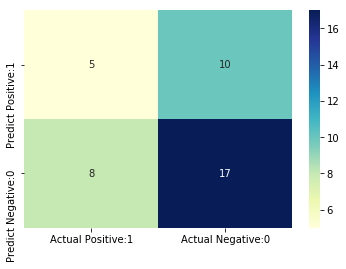

In [127]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

# **16. Classification metrices** <a class="anchor" id="16"></a>


[Table of Contents](#0.1)

## Classification Report


**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model. I have described these terms in later.

We can print a classification report as follows:-

In [128]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.38      0.33      0.36        15
           1       0.63      0.68      0.65        25

    accuracy                           0.55        40
   macro avg       0.51      0.51      0.51        40
weighted avg       0.54      0.55      0.54        40



## Classification accuracy

In [130]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [131]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))


Classification accuracy : 0.5500


## Classification error

In [132]:
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))


Classification error : 0.4500


## Precision


**Precision** can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP). 


So, **Precision** identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.



Mathematically, precision can be defined as the ratio of `TP to (TP + FP).`




In [133]:
# print precision score

precision = TP / float(TP + FP)


print('Precision : {0:0.4f}'.format(precision))


Precision : 0.3333


## Recall


Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes.
It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). **Recall** is also called **Sensitivity**.


**Recall** identifies the proportion of correctly predicted actual positives.


Mathematically, recall can be given as the ratio of `TP to (TP + FN).`





In [134]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 0.3846


## True Positive Rate


**True Positive Rate** is synonymous with **Recall**.


In [135]:
true_positive_rate = TP / float(TP + FN)


print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

True Positive Rate : 0.3846


## False Positive Rate

In [136]:
false_positive_rate = FP / float(FP + TN)


print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

False Positive Rate : 0.3704


## Specificity

In [137]:
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.6296


## f1-score


**f1-score** is the weighted harmonic mean of precision and recall. The best possible **f1-score** would be 1.0 and the worst 
would be 0.0.  **f1-score** is the harmonic mean of precision and recall. So, **f1-score** is always lower than accuracy measures as they embed precision and recall into their computation. The weighted average of `f1-score` should be used to 
compare classifier models, not global accuracy.



## Support


**Support** is the actual number of occurrences of the class in our dataset.

# **17. Adjusting the threshold level** <a class="anchor" id="17"></a>


[Table of Contents](#0.1)

In [138]:
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = logreg.predict_proba(X_test)[0:10]

y_pred_prob

array([[0.61261988, 0.38738012],
       [0.75393811, 0.24606189],
       [0.13690449, 0.86309551],
       [0.7487675 , 0.2512325 ],
       [0.85018417, 0.14981583],
       [0.35082775, 0.64917225],
       [0.22213137, 0.77786863],
       [0.21894974, 0.78105026],
       [0.58295488, 0.41704512],
       [0.31040792, 0.68959208]])

In [140]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - sub 70 KPI (0)', 'Prob of - > 70 (1)'])

y_pred_prob_df

,Prob of - sub 70 KPI (0),Prob of - > 70 (1)
0,0.612620,0.387380
1,0.753938,0.246062
2,0.136904,0.863096
3,0.748767,0.251233
4,0.850184,0.149816
5,0.350828,0.649172
6,0.222131,0.777869
7,0.218950,0.781050
8,0.582955,0.417045
9,0.310408,0.689592


In [144]:
# store the predicted probabilities for class 1 - Probability of high KPI

y_pred1 = logreg.predict_proba(X_test)[:, 1]

Text(0, 0.5, 'Frequency')

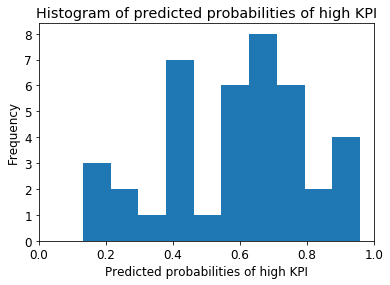

In [146]:
# plot histogram of predicted probabilities


# adjust the font size 
plt.rcParams['font.size'] = 12


# plot histogram with 10 bins
plt.hist(y_pred1, bins = 10)


# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of high KPI')


# set the x-axis limit
plt.xlim(0,1)


# set the title
plt.xlabel('Predicted probabilities of high KPI')
plt.ylabel('Frequency')

In [149]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, y_pred1)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.6613


In [150]:
# calculate cross-validated ROC AUC 

from sklearn.model_selection import cross_val_score

Cross_validated_ROC_AUC = cross_val_score(logreg, X_train, y_train, cv=5, scoring='roc_auc').mean()

print('Cross validated ROC AUC : {:.4f}'.format(Cross_validated_ROC_AUC))

Cross validated ROC AUC : 0.4967


[Go to Top](#0)